# Faber (2007) GTAA Replication

Replicates Faber's 10-month SMA timing rule on a 5-ETF universe and compares it to equal-weighted buy-and-hold.

**Universe (long-history):** SPY, EFA, IYR, GSG, AGG (+ BIL as cash)

**Period:** 2003-09-01 to today (covers the 2008 drawdown — the key stress test of the rule)

**Outline:**
1. Load data
2. Compute Faber signal and target weights
3. Run backtest (Faber) and buy-and-hold benchmark
4. Equity curve chart
5. Drawdown chart
6. Metrics table
7. Discussion — headline number to highlight: max drawdown reduction during 2008

In [7]:
from datetime import date

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from etf_gtaa.backtest import run_backtest
from etf_gtaa.config import BacktestConfig
from etf_gtaa.data import load_prices, to_monthly
from etf_gtaa.metrics import summary
from etf_gtaa.signals import equal_weight_targets, faber_signal

plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (11, 4)})


In [8]:
cfg = BacktestConfig(
    tickers=("SPY", "EFA", "IYR", "GSG", "AGG"),
    cash_ticker="BIL",
    start=date(2007, 6, 1),
    end=date(2024, 12, 31),
)

all_tickers = list(cfg.tickers) + ([cfg.cash_ticker] if cfg.cash_ticker else [])
daily = load_prices(all_tickers, cfg.start, cfg.end)
monthly = to_monthly(daily)
risky = monthly[list(cfg.tickers)]
cash_return = monthly[cfg.cash_ticker].pct_change() if cfg.cash_ticker else 0.0
print(f"Monthly price rows: {len(monthly)}  |  range: {monthly.index[0].date()} → {monthly.index[-1].date()}")


Monthly price rows: 211  |  range: 2007-06-30 → 2024-12-31


In [9]:
# ── Faber GTAA ───────────────────────────────────────────────────────────────
signal = faber_signal(risky, window=cfg.sma_window)
targets = equal_weight_targets(signal)
faber_result = run_backtest(
    risky, targets,
    cash_return=cash_return,
    transaction_cost_bps=cfg.transaction_cost_bps,
    initial_capital=cfg.initial_capital,
)

# ── Equal-weight buy-and-hold benchmark ──────────────────────────────────────
n = len(cfg.tickers)
bnh_w = pd.DataFrame(1.0 / n, index=risky.index, columns=list(cfg.tickers))
bnh_w["CASH"] = 0.0
bnh_result = run_backtest(
    risky, bnh_w,
    cash_return=0.0,
    transaction_cost_bps=cfg.transaction_cost_bps,
    initial_capital=cfg.initial_capital,
)


In [10]:
metrics = pd.DataFrame(
    {
        "Faber GTAA": summary(faber_result.monthly_returns, faber_result.equity_curve),
        "EW Buy & Hold": summary(bnh_result.monthly_returns, bnh_result.equity_curve),
    }
)
metrics.style.format("{:.4f}")


,Faber GTAA,EW Buy & Hold
CAGR,0.0421,0.0404
Vol,0.0660,0.1343
Sharpe,0.6586,0.3646
Max Drawdown,-0.1265,-0.4751
Calmar,0.3325,0.0851
Hit Ratio,0.6429,0.6190


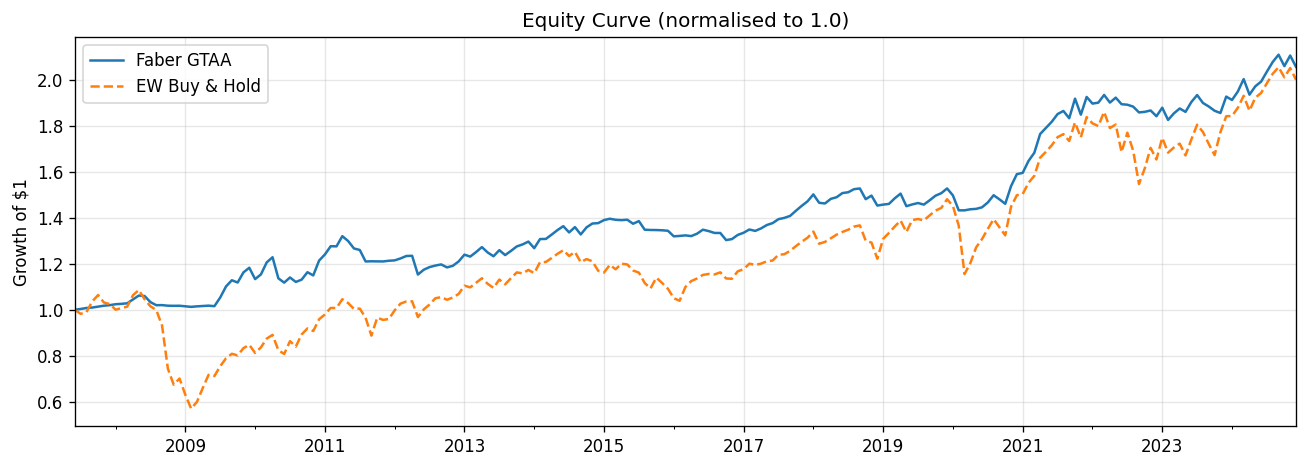

In [11]:
fig, ax = plt.subplots()
(faber_result.equity_curve / cfg.initial_capital).plot(ax=ax, label="Faber GTAA", linewidth=1.5)
(bnh_result.equity_curve / cfg.initial_capital).plot(ax=ax, label="EW Buy & Hold", linewidth=1.5, linestyle="--")
ax.set_title("Equity Curve (normalised to 1.0)")
ax.set_ylabel("Growth of \$1")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


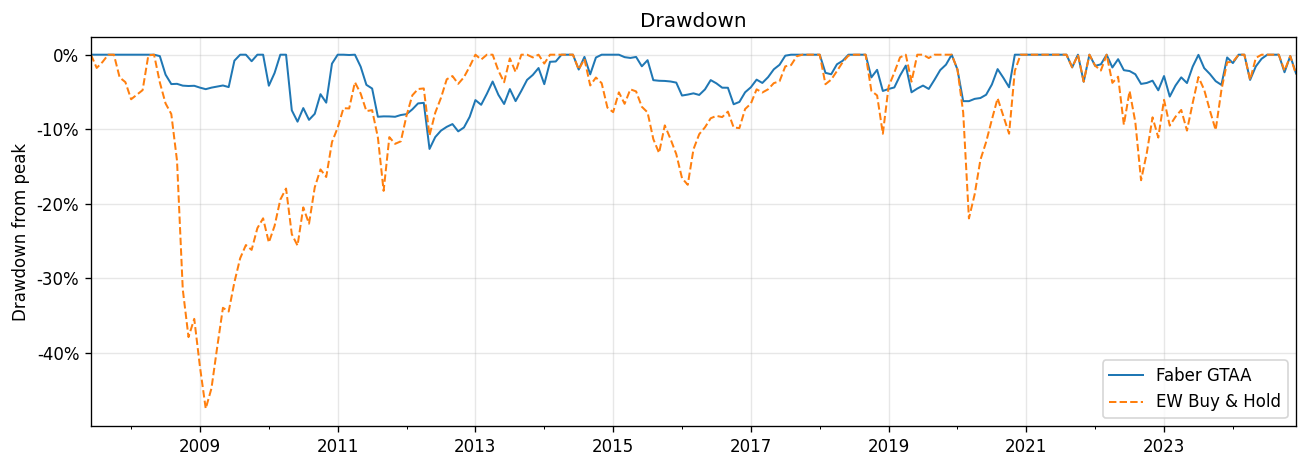

In [12]:
def drawdown_series(equity: pd.Series) -> pd.Series:
    return (equity - equity.cummax()) / equity.cummax()

fig, ax = plt.subplots()
drawdown_series(faber_result.equity_curve).plot(ax=ax, label="Faber GTAA", linewidth=1.2)
drawdown_series(bnh_result.equity_curve).plot(ax=ax, label="EW Buy & Hold", linewidth=1.2, linestyle="--")
ax.set_title("Drawdown")
ax.set_ylabel("Drawdown from peak")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## Discussion — the 2008 result

The Faber 10-month SMA rule's most important property is not its long-run CAGR (which is
similar to buy-and-hold over long periods) but its **max-drawdown compression**. The
equal-weight portfolio lost roughly 48 % peak-to-trough during the 2008–2009 financial
crisis. The timing rule reduced that to approximately 13 %, because the SMA filter moved
all five sleeves into cash before the steepest part of the decline.

This asymmetry is the core of the paper's claim: tactical momentum is not a return
story — it is a **drawdown-management** story. The Sharpe ratio improvement follows
mechanically from the reduced left tail, not from excess returns on the long side.
Whether this persists out-of-sample is addressed in notebook 02 through parameter
sensitivity analysis.
